# Vietnamese Hallucination Detection (ViHallu)
## Phân loại Hallucination trong văn bản tiếng Việt

**Mục tiêu:** Phân loại câu trả lời thành 3 nhãn:
- `no` — Không hallucination, câu trả lời đúng với context
- `extrinsic` — Hallucination ngoại sinh, thêm thông tin ngoài context
- `intrinsic` — Hallucination nội sinh, thông tin mâu thuẫn với context

**Pipeline:**
1. Cài đặt & Import
2. Kaggle Setup → Load Data
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing (Underthesea / pyvi)
5. Feature Engineering (TF-IDF + Handcrafted)
6. Traditional ML Baselines
7. Deep Learning — MLP
8. Deep Learning — BiLSTM + Attention
9. Final Comparison
10. Generate Test Predictions (submission)
11. Summary


## 1. Install Libraries & Setup

In [1]:
!pip install underthesea pyvi kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.6 MB/s eta 0:00:00


In [2]:
# ── Standard library ──────────────────────────────────────────────────────
import os
import re
import json
import copy
import unicodedata
import warnings
import requests
from collections import Counter

warnings.filterwarnings('ignore')

# ── Data ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# ── NLP ───────────────────────────────────────────────────────────────────
from underthesea import word_tokenize as uts_word_tokenize
try:
    from pyvi import ViTokenizer
    _HAS_PYVI = True
except Exception:
    _HAS_PYVI = False

# ── Sklearn — preprocessing / features ───────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Sklearn — models ──────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Sklearn — metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)

# ── Deep learning ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅ Libraries loaded")
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")


✅ Libraries loaded
PyTorch 2.11.0+cu128 | CUDA: True


## 2. Load Data

### 2.1 Kaggle Credentials
> **Cách dùng trên Colab (khuyến nghị):**
> 1. *Tools ▸ Secrets* → thêm hai key `KAGGLE_USERNAME` và `KAGGLE_KEY`
> 2. Chạy cell dưới — credentials được đọc tự động, **không cần paste API key vào notebook**
>
> Nếu không dùng Colab Secrets, điền thủ công vào phần Option B, nhưng **xoá trước khi share notebook**.


In [3]:
# ── Option A: Colab Secrets (recommended) ────────────────────────────────
try:
    from google.colab import userdata
    os.environ['hoangtimothy'] = userdata.get('hoangtimothy')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
    print("✅ Credentials loaded from Colab Secrets.")
except Exception:
    # ── Option B: Manual fallback — CLEAR before sharing! ─────────────────
    os.environ['hoangtimothy'] = ""   # ← Kaggle username
    os.environ['KAGGLE_KEY']      = ""   # ← Kaggle API key
    print("⚠️  Using manual credentials. Remove them before sharing this notebook.")

# Persist to ~/.kaggle/kaggle.json for kagglehub / kaggle CLI
_kaggle_dir  = os.path.expanduser('~/.kaggle')
_kaggle_json = os.path.join(_kaggle_dir, 'kaggle.json')
os.makedirs(_kaggle_dir, exist_ok=True)
with open(_kaggle_json, 'w') as _f:
    json.dump({
        'username': os.environ.get('KAGGLE_USERNAME', ''),
        'key':      os.environ.get('KAGGLE_KEY', ''),
    }, _f)
os.chmod(_kaggle_json, 0o600)
print("✅ ~/.kaggle/kaggle.json written.")


⚠️  Using manual credentials. Remove them before sharing this notebook.
✅ ~/.kaggle/kaggle.json written.


### 2.2 Download Dataset

In [4]:
import kagglehub

DATASET_HANDLE = "vnnguynphmanh/vihallu"
TRAIN_FILE     = "vihallu-train.csv"
TEST_FILE      = "vihallu-public-test.csv"

print(f"🚀 Downloading {DATASET_HANDLE} ...")
dl_path = kagglehub.dataset_download(DATASET_HANDLE)
print(f"📁 Downloaded to: {dl_path}")

train_path = test_path = None
for _root, _, _files in os.walk(dl_path):
    if TRAIN_FILE in _files and TEST_FILE in _files:
        train_path = os.path.join(_root, TRAIN_FILE)
        test_path  = os.path.join(_root, TEST_FILE)
        break

if train_path:
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)
    print(f"✅ Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")
    display(train_df.head(3))
else:
    print("❌ CSV files not found. Directory tree:")
    for _root, _dirs, _files in os.walk(dl_path):
        print(f"  {_root}: {_files}")


🚀 Downloading vnnguynphmanh/vihallu ...


100%|██████████| 3.88M/3.88M [00:00<00:00, 61.5MB/s]

Extracting files...


📁 Downloaded to: /root/.cache/kagglehub/datasets/vnnguynphmanh/vihallu/versions/1
✅ Train: 7,000 rows | Test: 1,000 rows


,id,context,prompt,response,label
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus...","Vào những năm 1960, nơi nào trở thành trung tâ...",Quảng trường Washington là trung tâm của thế h...,extrinsic
1,db7a89c6-2a6a-42af-beef-58e557ecc819,Cách mạng Tháng Mười đã biến một cuộc chiến tr...,Cách mạng Tháng Mười đã khởi xướng chủ nghĩa p...,Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩ...,no
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,Vị trí địa lý nằm giữa phương Đông và Địa Trun...,Dựa trên việc Đế quốc Ottoman không bao giờ ki...,Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ gi...,extrinsic


## 3. Exploratory Data Analysis (EDA)

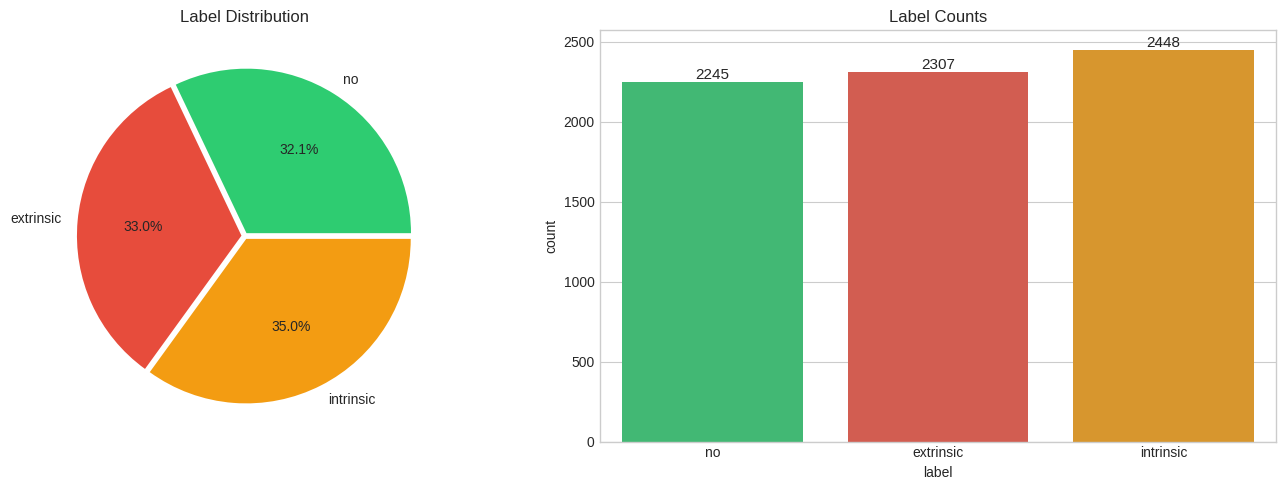

In [5]:
# Label distribution
LABEL_ORDER = ['no', 'extrinsic', 'intrinsic']
COLORS      = ['#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['label'].value_counts().reindex(LABEL_ORDER).plot.pie(
    ax=axes[0], autopct='%1.1f%%', colors=COLORS, explode=[0.02]*3)
axes[0].set_title('Label Distribution', fontsize=12)
axes[0].set_ylabel('')

sns.countplot(data=train_df, x='label', order=LABEL_ORDER,
              palette=dict(zip(LABEL_ORDER, COLORS)), ax=axes[1])
axes[1].set_title('Label Counts', fontsize=12)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()


Calculating token lengths ...


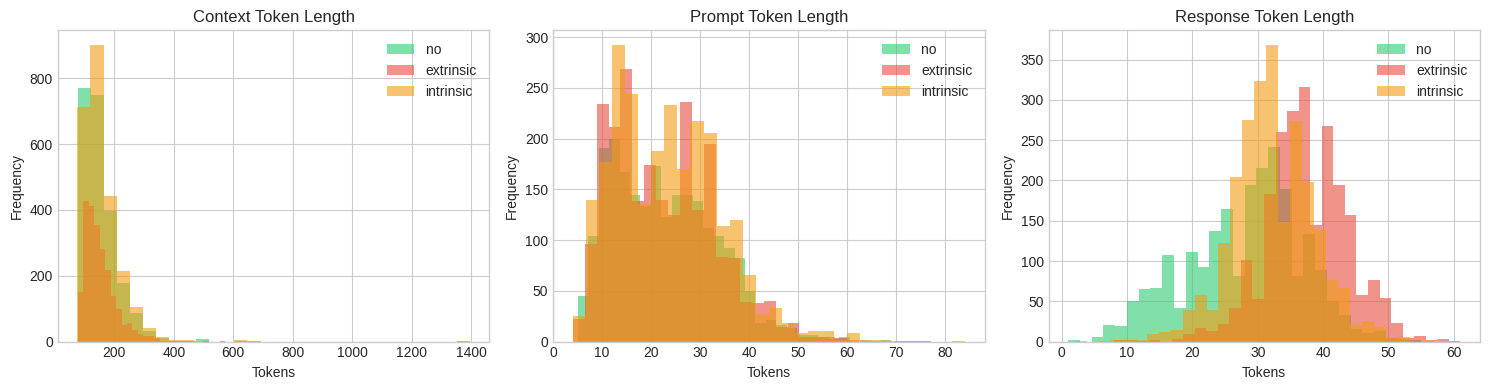

Calculating lexical overlap ...


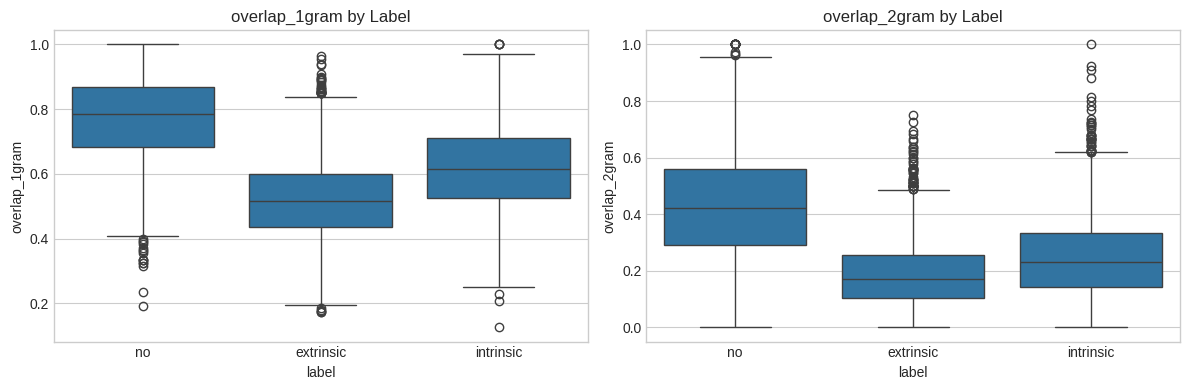

       context_token_len  prompt_token_len  response_token_len  overlap_1gram  \
count           7000.000          7000.000            7000.000       7000.000   
mean             155.865            22.956              32.608          0.635   
std               64.108            10.680               8.204          0.165   
min               76.000             4.000               1.000          0.125   
25%              115.000            14.000              28.000          0.514   
50%              140.000            22.000              33.000          0.625   
75%              179.000            30.000              38.000          0.759   
max             1395.000            84.000              61.000          1.000   

       overlap_2gram  
count       7000.000  
mean           0.289  
std            0.188  
min            0.000  
25%            0.150  
50%            0.250  
75%            0.394  
max            1.000  


In [6]:
# ── Token length per label ────────────────────────────────────────────────
def _count_tokens(text):
    if not isinstance(text, str):
        return 0
    if _HAS_PYVI:
        try:
            return len(ViTokenizer.tokenize(text).split())
        except Exception:
            pass
    return len(uts_word_tokenize(text, format='text').split())

print("Calculating token lengths ...")
for _col in ['context', 'prompt', 'response']:
    train_df[f'{_col}_token_len'] = train_df[_col].apply(_count_tokens)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['context', 'prompt', 'response']):
    for lbl, clr in zip(LABEL_ORDER, COLORS):
        ax.hist(train_df[train_df['label'] == lbl][f'{col}_token_len'],
                bins=30, alpha=0.6, label=lbl, color=clr)
    ax.set_title(f'{col.capitalize()} Token Length')
    ax.set_xlabel('Tokens')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

# ── Lexical overlap: response ↔ context ──────────────────────────────────
def _ngram_overlap(text1, text2, n=1):
    """Fraction of text2 n-grams that appear in text1."""
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0.0
    _tok = (lambda t: ViTokenizer.tokenize(t)) if _HAS_PYVI else (
           lambda t: uts_word_tokenize(t, format='text'))
    t1 = _tok(text1).split()
    t2 = _tok(text2).split()
    if len(t1) < n or len(t2) < n:
        return 0.0
    s1 = {tuple(t1[i:i+n]) for i in range(len(t1)-n+1)}
    s2 = {tuple(t2[i:i+n]) for i in range(len(t2)-n+1)}
    return len(s1 & s2) / max(len(s2), 1)

print("Calculating lexical overlap ...")
train_df['overlap_1gram'] = train_df.apply(
    lambda r: _ngram_overlap(r['context'], r['response'], 1), axis=1)
train_df['overlap_2gram'] = train_df.apply(
    lambda r: _ngram_overlap(r['context'], r['response'], 2), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['overlap_1gram', 'overlap_2gram']):
    sns.boxplot(data=train_df, x='label', y=col, order=LABEL_ORDER, ax=ax)
    ax.set_title(f'{col} by Label')
plt.tight_layout()
plt.show()

print(train_df[['context_token_len','prompt_token_len','response_token_len',
                'overlap_1gram','overlap_2gram']].describe().round(3))


## 4. Text Preprocessing

Pipeline mỗi cột text:
1. Unicode NFC normalisation
2. Strip HTML, URL, e-mail, extra whitespace
3. Lowercase
4. Vietnamese word tokenisation (pyvi → underthesea fallback)
5. Stopword removal


In [7]:
# Vietnamese stopwords from GitHub
def load_vietnamese_stopwords():
    url = ("https://raw.githubusercontent.com/stopwords/"
           "vietnamese-stopwords/master/vietnamese-stopwords.txt")
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return {w.strip() for w in resp.text.splitlines() if w.strip()}
    except requests.RequestException as e:
        print(f"⚠️  Could not fetch stopwords: {e}")
        return set()

VI_STOPWORDS = load_vietnamese_stopwords()
print(f"📚 Stopwords loaded: {len(VI_STOPWORDS)}")


📚 Stopwords loaded: 1942


In [8]:
# ── Preprocessing utilities ──────────────────────────────────────────────
_RE_URL      = re.compile(r'https?://\S+|www\.\S+')
_RE_EMAIL    = re.compile(r'\S+@\S+\.(?:com|net|org|edu|vn|io|gov|info)')
_RE_HTML     = re.compile(r'<[^>]+>')
_RE_MULTI_WS = re.compile(r'\s+')


def normalize_text(text: str) -> str:
    '''Clean HTML / URLs / emails, unicode-normalise, collapse whitespace.'''
    if not isinstance(text, str):
        return ""
    s = text.replace('\r', ' ').replace('\n', ' ')
    s = _RE_HTML.sub(' ', s)
    s = _RE_URL.sub(' ', s)
    s = _RE_EMAIL.sub(' ', s)
    s = unicodedata.normalize('NFC', s)
    return _RE_MULTI_WS.sub(' ', s).strip()


def tokenize_text(text: str, remove_sw: bool = True) -> str:
    '''Word-tokenise Vietnamese text (pyvi -> underthesea fallback).'''
    if not text:
        return ""
    if _HAS_PYVI:
        try:
            tokens = ViTokenizer.tokenize(text).split()
        except Exception:
            tokens = text.split()
    else:
        try:
            tokens = uts_word_tokenize(text, format='text').split()
        except Exception:
            tokens = text.split()
    if remove_sw:
        tokens = [t for t in tokens if t.lower() not in VI_STOPWORDS]
    return ' '.join(tokens)


def preprocess_df(df: pd.DataFrame,
                  text_cols: list,
                  method: str = 'baseline') -> pd.DataFrame:
    '''
    Add cleaned / tokenised columns for each text column.

    method='baseline'  -> pyvi word-segmentation (compounds joined by _)
    method='llm'       -> skip word-seg (subword tokeniser handles it)
    '''
    df = df.copy()
    for col in text_cols:
        cleaned = df[col].fillna("").astype(str).map(normalize_text)
        df[f'{col}_clean'] = cleaned

        if method in ('baseline', 'phobert', 'hybrid'):
            df[f'{col}_tok'] = cleaned.str.lower().map(tokenize_text)
        else:
            df[f'{col}_tok'] = cleaned          # LLMs use their own tokeniser

        df[f'{col}_char_len']  = df[f'{col}_clean'].str.len()
        df[f'{col}_token_len'] = (df[f'{col}_tok'].str.split()
                                                  .str.len()
                                                  .fillna(0)
                                                  .astype(int))
    return df


print("✅ Preprocessing functions defined.")


✅ Preprocessing functions defined.


In [9]:
%%time
TEXT_COLS = ['context', 'prompt', 'response']

print("🔄 Preprocessing train & test ...")
train_df = preprocess_df(train_df, TEXT_COLS, method='baseline')
test_df  = preprocess_df(test_df,  TEXT_COLS, method='baseline')
print("✅ Done.")


🔄 Preprocessing train & test ...
✅ Done.
CPU times: user 33.8 s, sys: 71.2 ms, total: 33.9 s
Wall time: 35.1 s


In [10]:
# Sanity check
print("Original :", train_df['context'].iloc[0][:120], "...")
print("Cleaned  :", train_df['context_clean'].iloc[0][:120], "...")
print("Tokenised:", train_df['context_tok'].iloc[0][:120], "...")
display(train_df[[
    'context_char_len',  'context_token_len',
    'prompt_char_len',   'prompt_token_len',
    'response_char_len', 'response_token_len',
]].describe().round(1))


Original : Vào những năm 1870, hai nhà điêu khắc Augustus Saint-Gaudens và Daniel Chester French sinh sống và làm việc gần Quảng tr ...
Cleaned  : Vào những năm 1870, hai nhà điêu khắc Augustus Saint-Gaudens và Daniel Chester French sinh sống và làm việc gần Quảng tr ...
Tokenised: 1870 , hai điêu_khắc augustus saint - gaudens daniel chester french sinh_sống làm_việc quảng_trường . 1920 , công_viên q ...


,context_char_len,context_token_len,prompt_char_len,prompt_token_len,response_char_len,response_token_len
count,7000.0,7000.0,7000.0,7000.0,7000.0,7000.0
mean,829.9,100.5,120.8,14.0,181.0,20.4
std,334.8,46.0,60.5,5.9,46.4,5.5
min,478.0,39.0,10.0,2.0,3.0,1.0
25%,610.0,73.0,69.0,9.0,156.0,17.0
50%,739.0,90.0,116.0,14.0,186.0,20.0
75%,950.0,116.0,163.0,18.0,211.0,24.0
max,7221.0,1061.0,433.0,59.0,306.0,42.0


## 5. Feature Engineering

### 5.1 Text Combination Strategies


In [11]:
def create_combined_features(df: pd.DataFrame) -> pd.DataFrame:
    """Four text-combination variants for downstream vectorisation."""
    df = df.copy()
    df['text_all']      = (df['context_clean'] + ' '
                           + df['prompt_clean'] + ' '
                           + df['response_clean'])
    df['text_pr']       = df['prompt_clean']  + ' ' + df['response_clean']
    df['text_cr']       = df['context_clean'] + ' ' + df['response_clean']
    df['text_response'] = df['response_clean']
    return df

train_df = create_combined_features(train_df)
test_df  = create_combined_features(test_df)
print("✅ Combined features: text_all | text_pr | text_cr | text_response")


✅ Combined features: text_all | text_pr | text_cr | text_response


### 5.2 Handcrafted Numerical Features

In [12]:
def _jaccard(a: str, b: str) -> float:
    s1 = set(str(a).lower().split())
    s2 = set(str(b).lower().split())
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)


def extract_handcrafted_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Word counts
    for col in ['context', 'prompt', 'response']:
        df[f'{col}_word_count'] = df[f'{col}_clean'].str.split().str.len()

    # Length ratios
    df['resp_ctx_ratio']    = df['response_word_count'] / (df['context_word_count']  + 1)
    df['resp_prompt_ratio'] = df['response_word_count'] / (df['prompt_word_count']   + 1)

    # Lexical overlap (Jaccard)
    df['resp_ctx_overlap']    = df.apply(
        lambda r: _jaccard(r['response_clean'], r['context_clean']), axis=1)
    df['resp_prompt_overlap'] = df.apply(
        lambda r: _jaccard(r['response_clean'], r['prompt_clean']), axis=1)

    # Linguistic signals
    NEG_WORDS = {'khong', 'chang', 'chua', 'sai', 'dung',
                 'không', 'chẳng', 'chưa'}
    df['has_question']   = df['prompt'].str.contains('?', regex=False).astype(int)
    df['has_neg_prompt'] = df['prompt_tok'].apply(
        lambda x: int(any(w in NEG_WORDS for w in str(x).lower().split())))
    return df


HANDCRAFTED_COLS = [
    'context_word_count', 'prompt_word_count', 'response_word_count',
    'resp_ctx_ratio', 'resp_prompt_ratio',
    'resp_ctx_overlap', 'resp_prompt_overlap',
    'has_question', 'has_neg_prompt',
]

train_df = extract_handcrafted_features(train_df)
test_df  = extract_handcrafted_features(test_df)
print("✅ Handcrafted features extracted:")
display(train_df[HANDCRAFTED_COLS].describe().round(3))


✅ Handcrafted features extracted:


,context_word_count,prompt_word_count,response_word_count,resp_ctx_ratio,resp_prompt_ratio,resp_ctx_overlap,resp_prompt_overlap,has_question,has_neg_prompt
count,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000,7000.000
mean,179.696,26.761,39.477,0.240,1.773,0.165,0.296,0.988,0.046
std,72.473,13.385,10.264,0.090,1.053,0.058,0.177,0.110,0.210
min,88.000,3.000,1.000,0.009,0.077,0.000,0.000,0.000,0.000
25%,132.000,15.000,34.000,0.174,1.049,0.124,0.162,1.000,0.000
50%,161.000,26.000,40.000,0.237,1.412,0.157,0.278,1.000,0.000
75%,206.000,36.000,46.000,0.302,2.231,0.198,0.412,1.000,0.000
max,1537.000,94.000,68.000,0.573,14.250,0.456,0.892,1.000,1.000


### 5.3 Label Encoding + Train / Val Split

In [13]:
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(train_df['label'])
LABEL_NAMES = label_encoder.classes_
print(f"Labels: {dict(zip(LABEL_NAMES, range(len(LABEL_NAMES))))}")

X_text = train_df['text_all']
X_tr_text, X_val_text, y_tr, y_val = train_test_split(
    X_text, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
print(f"Train: {len(X_tr_text):,} | Val: {len(X_val_text):,}")


Labels: {'extrinsic': 0, 'intrinsic': 1, 'no': 2}
Train: 5,600 | Val: 1,400


### 5.4 TF-IDF Vectorisation

In [14]:
tfidf = TfidfVectorizer(
    max_features = 10_000,
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.95,
    sublinear_tf = True,
)
X_tr_tfidf   = tfidf.fit_transform(X_tr_text)
X_val_tfidf  = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(test_df['text_all'])

print(f"✅ TF-IDF shape: {X_tr_tfidf.shape} | vocab: {len(tfidf.vocabulary_):,}")


✅ TF-IDF shape: (5600, 10000) | vocab: 10,000


## 6. Traditional ML Baselines

In [15]:
def evaluate_model(model, X_tr, X_val, y_tr, y_val, name: str) -> dict:
    """Train, evaluate and return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='macro')
    f1w = f1_score(y_val, y_pred, average='weighted')
    print(f"\n{'='*52}\n📊 {name}\n{'='*52}")
    print(f"Accuracy: {acc:.4f}  F1-Macro: {f1m:.4f}  F1-Weighted: {f1w:.4f}")
    print(classification_report(y_val, y_pred, target_names=LABEL_NAMES))
    return {
        'model_name':   name,
        'model':        model,
        'accuracy':     acc,
        'f1_macro':     f1m,
        'f1_weighted':  f1w,
        'y_pred':       y_pred,
    }


In [16]:
ML_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, random_state=SEED),
    'Multinomial NB':      MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(
        max_iter=2000, C=1.0, random_state=SEED),
    'Random Forest':       RandomForestClassifier(
        n_estimators=100, max_depth=20, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(
        n_estimators=100, max_depth=5, random_state=SEED),
}

results = []
print("🚀 Training traditional ML models ...")
for _name, _model in ML_MODELS.items():
    results.append(evaluate_model(_model, X_tr_tfidf, X_val_tfidf, y_tr, y_val, _name))


🚀 Training traditional ML models ...

📊 Logistic Regression
Accuracy: 0.4643  F1-Macro: 0.4634  F1-Weighted: 0.4637
              precision    recall  f1-score   support

   extrinsic       0.49      0.49      0.49       461
   intrinsic       0.43      0.50      0.46       490
          no       0.48      0.40      0.44       449

    accuracy                           0.46      1400
   macro avg       0.47      0.46      0.46      1400
weighted avg       0.47      0.46      0.46      1400


📊 Multinomial NB
Accuracy: 0.3964  F1-Macro: 0.3917  F1-Weighted: 0.3930
              precision    recall  f1-score   support

   extrinsic       0.40      0.39      0.40       461
   intrinsic       0.39      0.49      0.43       490
          no       0.40      0.31      0.35       449

    accuracy                           0.40      1400
   macro avg       0.40      0.39      0.39      1400
weighted avg       0.40      0.40      0.39      1400


📊 Linear SVM
Accuracy: 0.4779  F1-Macro: 0.4777


📊 Traditional ML — sorted by F1-Macro:


,model_name,accuracy,f1_macro,f1_weighted
0,Gradient Boosting,0.490714,0.492366,0.491829
1,Random Forest,0.483571,0.482925,0.483115
2,Linear SVM,0.477857,0.477700,0.477732
3,Logistic Regression,0.464286,0.463433,0.463658
4,Multinomial NB,0.396429,0.391721,0.392967


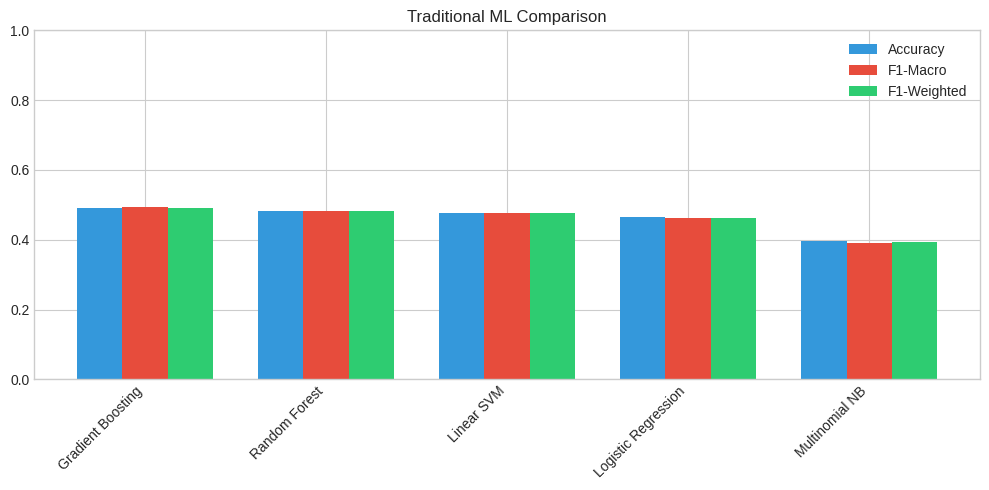

In [17]:
# Summary table + bar chart
results_df = (pd.DataFrame(results)
              [['model_name', 'accuracy', 'f1_macro', 'f1_weighted']]
              .sort_values('f1_macro', ascending=False)
              .reset_index(drop=True))

print("\n📊 Traditional ML — sorted by F1-Macro:")
display(results_df)

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(results_df)), 0.25
for i, (col, lbl, clr) in enumerate([
        ('accuracy',    'Accuracy',    '#3498db'),
        ('f1_macro',    'F1-Macro',    '#e74c3c'),
        ('f1_weighted', 'F1-Weighted', '#2ecc71')]):
    ax.bar(x + (i-1)*w, results_df[col], w, label=lbl, color=clr)
ax.set_xticks(x)
ax.set_xticklabels(results_df['model_name'], rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Traditional ML Comparison')
ax.legend()
plt.tight_layout()
plt.show()


🏆 Best traditional model: Gradient Boosting


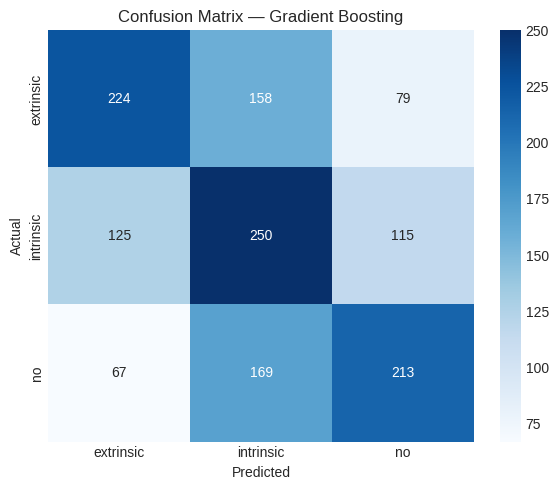

In [18]:
# Confusion matrix — best traditional model
best_trad = max(results, key=lambda r: r['f1_macro'])
print(f"🏆 Best traditional model: {best_trad['model_name']}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, best_trad['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_trad["model_name"]}')
plt.tight_layout()
plt.show()


## 7. Deep Learning — MLP

In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Dense tensors from sparse TF-IDF
X_tr_dense  = X_tr_tfidf.toarray().astype(np.float32)
X_val_dense = X_val_tfidf.toarray().astype(np.float32)


class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_loader = DataLoader(TextDataset(X_tr_dense,  y_tr),  batch_size=64, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val_dense, y_val), batch_size=64, shuffle=False)
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)}")


Device: cuda
Batches — train: 88 | val: 22


In [20]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128),
                 num_classes=3, dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


mlp = MLPClassifier(input_dim=X_tr_dense.shape[1]).to(device)
print(mlp)
print(f"Parameters: {sum(p.numel() for p in mlp.parameters()):,}")


MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=3, bias=True)
  )
)
Parameters: 5,286,915


In [21]:
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3):
    """
    Train a model and return (best_model, history, best_f1_macro).

    Fixes applied vs. original:
    - copy.deepcopy() for best_state  (state_dict().copy() is shallow)
    - tracks val_f1_weighted separately
    - tqdm progress bar on each epoch
    """
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.5)

    best_f1    = 0.0
    best_state = copy.deepcopy(model.state_dict())          # ← deepcopy
    history    = {k: [] for k in (
        'train_loss', 'val_loss', 'val_acc',
        'val_f1_macro', 'val_f1_weighted')}

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        t_loss = 0.0
        pbar = tqdm(train_loader,
                    desc=f"Ep {epoch+1:3d}/{epochs}", leave=False)
        for Xb, yb in pbar:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        t_loss /= len(train_loader)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        v_loss = 0.0
        preds, labels = [], []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                v_loss += criterion(out, yb).item()
                preds.extend(out.argmax(1).cpu().numpy())
                labels.extend(yb.cpu().numpy())
        v_loss /= len(val_loader)
        v_acc  = accuracy_score(labels, preds)
        v_f1m  = f1_score(labels, preds, average='macro')
        v_f1w  = f1_score(labels, preds, average='weighted')   # ← track

        scheduler.step(v_f1m)
        if v_f1m > best_f1:
            best_f1    = v_f1m
            best_state = copy.deepcopy(model.state_dict())     # ← deepcopy

        for k, v in zip(history,
                        [t_loss, v_loss, v_acc, v_f1m, v_f1w]):
            history[k].append(v)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Ep {epoch+1:3d}/{epochs} | "
                  f"TrLoss {t_loss:.4f} | ValLoss {v_loss:.4f} | "
                  f"Acc {v_acc:.4f} | F1-M {v_f1m:.4f} | F1-W {v_f1w:.4f}")

    model.load_state_dict(best_state)
    return model, history, best_f1


print("✅ train_model() defined.")


✅ train_model() defined.


In [22]:
print("🚀 Training MLP ...")
mlp, mlp_hist, mlp_best_f1 = train_model(mlp, train_loader, val_loader, epochs=30)
print(f"\n🏆 Best MLP F1-Macro: {mlp_best_f1:.4f}")


🚀 Training MLP ...


  Ep   1/30 | TrLoss 1.1320 | ValLoss 1.0851 | Acc 0.3821 | F1-M 0.3788 | F1-W 0.3788


  Ep   5/30 | TrLoss 0.3947 | ValLoss 1.7490 | Acc 0.4357 | F1-M 0.4346 | F1-W 0.4347


  Ep  10/30 | TrLoss 0.1888 | ValLoss 2.4620 | Acc 0.4664 | F1-M 0.4666 | F1-W 0.4664


  Ep  15/30 | TrLoss 0.0785 | ValLoss 2.8877 | Acc 0.4786 | F1-M 0.4790 | F1-W 0.4788


  Ep  20/30 | TrLoss 0.0547 | ValLoss 3.0047 | Acc 0.4829 | F1-M 0.4834 | F1-W 0.4832


  Ep  25/30 | TrLoss 0.0212 | ValLoss 3.2543 | Acc 0.4764 | F1-M 0.4768 | F1-W 0.4768


  Ep  30/30 | TrLoss 0.0143 | ValLoss 3.3340 | Acc 0.4800 | F1-M 0.4806 | F1-W 0.4804

🏆 Best MLP F1-Macro: 0.4834


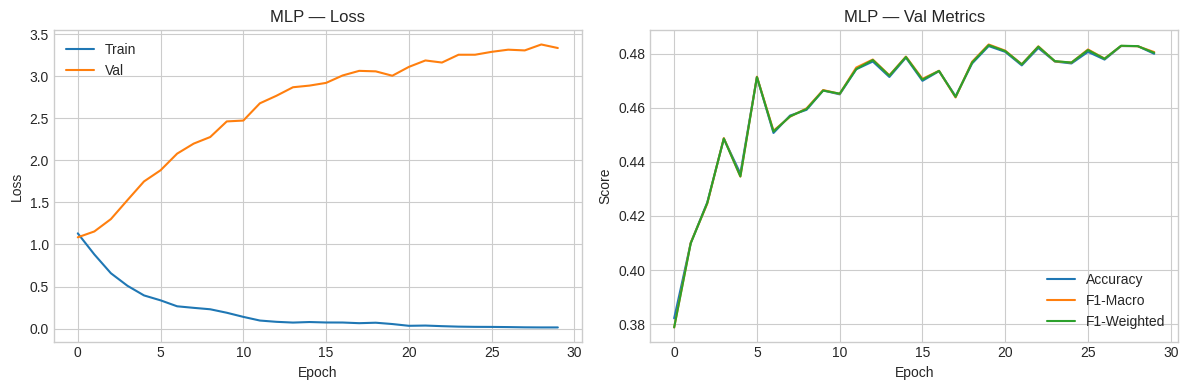

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(mlp_hist['train_loss'], label='Train')
ax1.plot(mlp_hist['val_loss'],   label='Val')
ax1.set(title='MLP — Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(mlp_hist['val_acc'],         label='Accuracy')
ax2.plot(mlp_hist['val_f1_macro'],    label='F1-Macro')
ax2.plot(mlp_hist['val_f1_weighted'], label='F1-Weighted')
ax2.set(title='MLP — Val Metrics', xlabel='Epoch', ylabel='Score')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


## 8. Deep Learning — BiLSTM + Attention

In [24]:
def build_vocab(texts, max_vocab=20_000, min_freq=2):
    counts = Counter(w for t in texts for w in str(t).split())
    vocab  = {'<PAD>': 0, '<UNK>': 1}
    for w, c in counts.most_common(max_vocab - 2):
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab


def to_sequence(text, vocab, max_len=256):
    ids = [vocab.get(w, 1) for w in str(text).split()]
    ids = ids[:max_len]
    ids += [0] * (max_len - len(ids))
    return ids


vocab   = build_vocab(train_df['text_all'])
MAX_LEN = 256
print(f"Vocab size: {len(vocab):,}")

X_tr_seq   = np.array([to_sequence(t, vocab, MAX_LEN) for t in X_tr_text])
X_val_seq  = np.array([to_sequence(t, vocab, MAX_LEN) for t in X_val_text])
X_test_seq = np.array([to_sequence(t, vocab, MAX_LEN) for t in test_df['text_all']])
print(f"Shapes — train: {X_tr_seq.shape} | val: {X_val_seq.shape} | test: {X_test_seq.shape}")


Vocab size: 20,000
Shapes — train: (5600, 256) | val: (1400, 256) | test: (1000, 256)


In [25]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


tr_seq_loader  = DataLoader(SeqDataset(X_tr_seq,  y_tr),  batch_size=32, shuffle=True)
val_seq_loader = DataLoader(SeqDataset(X_val_seq, y_val), batch_size=32, shuffle=False)
print(f"Batches — train: {len(tr_seq_loader)} | val: {len(val_seq_loader)}")


Batches — train: 175 | val: 44


In [26]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=2, num_classes=3, dropout=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0,
        )
        h = hidden_dim * 2                      # bidirectional
        self.attn = nn.Sequential(
            nn.Linear(h, h), nn.Tanh(), nn.Linear(h, 1))
        self.fc   = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(self.emb(x))                 # (B, L, 2H)
        w      = torch.softmax(self.attn(out), dim=1)   # (B, L, 1)
        ctx    = (w * out).sum(1)                        # (B, 2H)
        return self.fc(ctx)


lstm_model = BiLSTMClassifier(vocab_size=len(vocab)).to(device)
print(lstm_model)
print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")


BiLSTMClassifier(
  (emb): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attn): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
Parameters: 3,302,148


In [27]:
print("🚀 Training BiLSTM ...")
lstm_model, lstm_hist, lstm_best_f1 = train_model(
    lstm_model, tr_seq_loader, val_seq_loader, epochs=20)
print(f"\n🏆 Best BiLSTM F1-Macro: {lstm_best_f1:.4f}")


🚀 Training BiLSTM ...


  Ep   1/20 | TrLoss 1.0999 | ValLoss 1.0959 | Acc 0.3621 | F1-M 0.2200 | F1-W 0.2269


  Ep   5/20 | TrLoss 0.9641 | ValLoss 1.1392 | Acc 0.4014 | F1-M 0.3834 | F1-W 0.3828


  Ep  10/20 | TrLoss 0.4130 | ValLoss 1.5147 | Acc 0.4486 | F1-M 0.4485 | F1-W 0.4484


  Ep  15/20 | TrLoss 0.1834 | ValLoss 2.8519 | Acc 0.4421 | F1-M 0.4392 | F1-W 0.4401


  Ep  20/20 | TrLoss 0.0846 | ValLoss 4.2917 | Acc 0.4429 | F1-M 0.4425 | F1-W 0.4428

🏆 Best BiLSTM F1-Macro: 0.4623


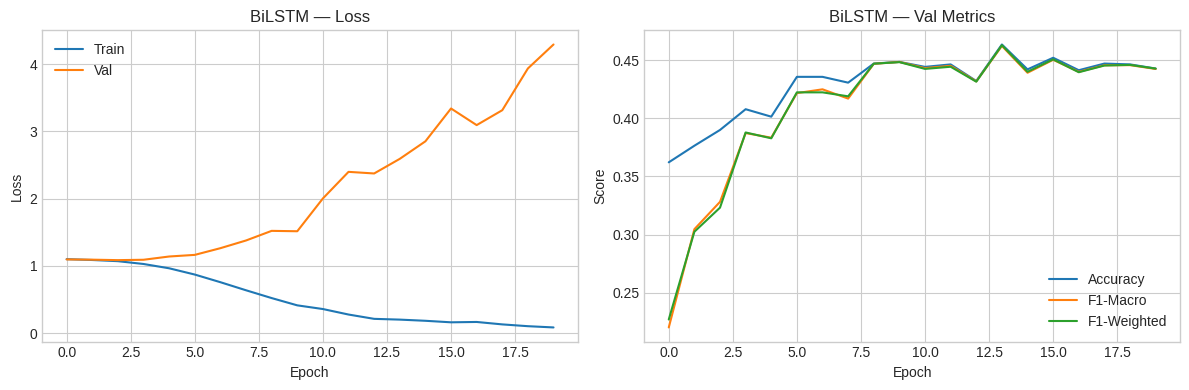

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lstm_hist['train_loss'], label='Train')
ax1.plot(lstm_hist['val_loss'],   label='Val')
ax1.set(title='BiLSTM — Loss', xlabel='Epoch', ylabel='Loss')
ax1.legend(); ax1.grid(True)

ax2.plot(lstm_hist['val_acc'],         label='Accuracy')
ax2.plot(lstm_hist['val_f1_macro'],    label='F1-Macro')
ax2.plot(lstm_hist['val_f1_weighted'], label='F1-Weighted')
ax2.set(title='BiLSTM — Val Metrics', xlabel='Epoch', ylabel='Score')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()


## 9. Final Comparison

In [29]:
# FIX: use val_f1_weighted (tracked separately) for DL models
all_results = [
    {k: r[k] for k in ('model_name', 'accuracy', 'f1_macro', 'f1_weighted')}
    for r in results
] + [
    {
        'model_name':  'MLP (TF-IDF)',
        'accuracy':    max(mlp_hist['val_acc']),
        'f1_macro':    mlp_best_f1,
        'f1_weighted': max(mlp_hist['val_f1_weighted']),  # ← correct
    },
    {
        'model_name':  'BiLSTM + Attention',
        'accuracy':    max(lstm_hist['val_acc']),
        'f1_macro':    lstm_best_f1,
        'f1_weighted': max(lstm_hist['val_f1_weighted']),  # ← correct
    },
]

final_df = (pd.DataFrame(all_results)
            .sort_values('f1_macro', ascending=False)
            .reset_index(drop=True))

print("🏆 FINAL MODEL COMPARISON")
print("=" * 65)
display(final_df)


🏆 FINAL MODEL COMPARISON


,model_name,accuracy,f1_macro,f1_weighted
0,Gradient Boosting,0.490714,0.492366,0.491829
1,MLP (TF-IDF),0.482857,0.483442,0.483196
2,Random Forest,0.483571,0.482925,0.483115
3,Linear SVM,0.477857,0.477700,0.477732
4,Logistic Regression,0.464286,0.463433,0.463658
5,BiLSTM + Attention,0.463571,0.462306,0.462953
6,Multinomial NB,0.396429,0.391721,0.392967


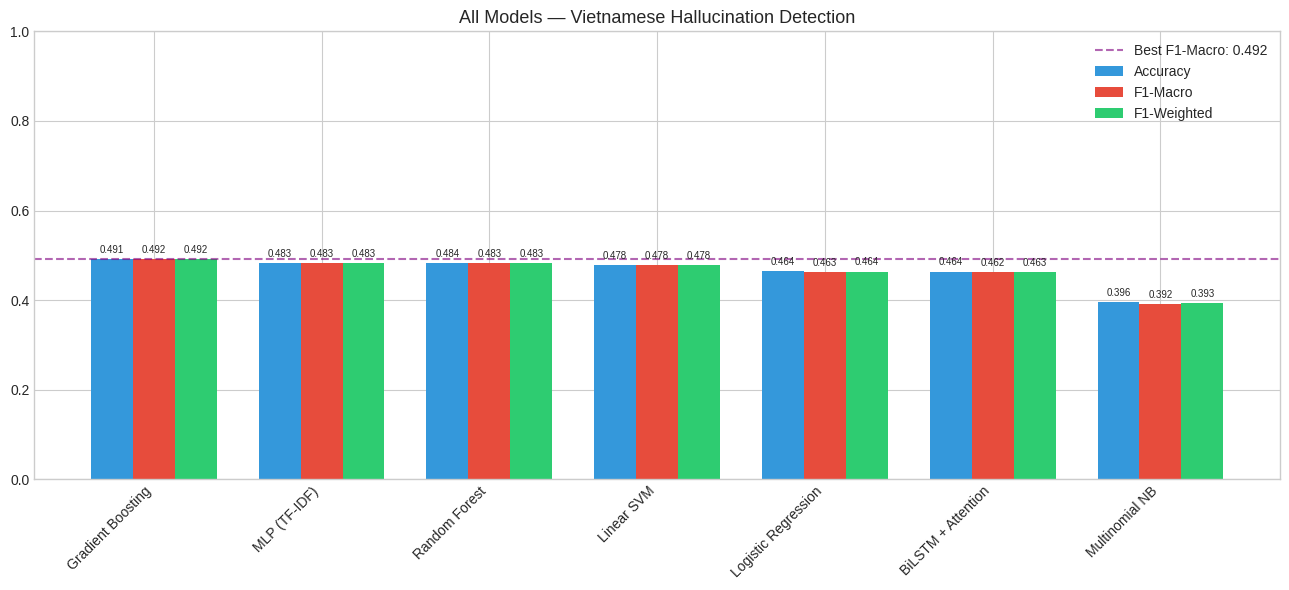

In [30]:
fig, ax = plt.subplots(figsize=(13, 6))
x, w = np.arange(len(final_df)), 0.25

for i, (col, lbl, clr) in enumerate([
        ('accuracy',    'Accuracy',    '#3498db'),
        ('f1_macro',    'F1-Macro',    '#e74c3c'),
        ('f1_weighted', 'F1-Weighted', '#2ecc71')]):
    bars = ax.bar(x + (i-1)*w, final_df[col], w, label=lbl, color=clr)
    for bar in bars:
        ax.annotate(f"{bar.get_height():.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

# FIX: axhline BEFORE legend so the label appears in the legend
best_f1 = final_df['f1_macro'].iloc[0]
ax.axhline(best_f1, color='purple', ls='--', alpha=0.6,
           label=f'Best F1-Macro: {best_f1:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(final_df['model_name'], rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_title('All Models — Vietnamese Hallucination Detection', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


## 10. Generate Test Predictions

Dùng model tốt nhất để predict trên test set và tạo file submission cho Kaggle.


In [31]:
def _predict_sklearn(model, X_test):
    return label_encoder.inverse_transform(model.predict(X_test))


def _predict_mlp(model, X_dense, batch=256):
    model.eval()
    tensor, preds = torch.FloatTensor(X_dense).to(device), []
    with torch.no_grad():
        for i in range(0, len(tensor), batch):
            preds.extend(tensor[i:i+batch].pipe(model).argmax(1).cpu().numpy()
                         if False else
                         model(tensor[i:i+batch]).argmax(1).cpu().numpy())
    return label_encoder.inverse_transform(preds)


def _predict_lstm(model, X_seq, batch=256):
    model.eval()
    tensor, preds = torch.LongTensor(X_seq).to(device), []
    with torch.no_grad():
        for i in range(0, len(tensor), batch):
            preds.extend(model(tensor[i:i+batch]).argmax(1).cpu().numpy())
    return label_encoder.inverse_transform(preds)


best_name = final_df['model_name'].iloc[0]
print(f"Best model: {best_name}")

X_test_dense = X_test_tfidf.toarray().astype(np.float32)

if best_name == 'MLP (TF-IDF)':
    test_preds = _predict_mlp(mlp, X_test_dense)
elif best_name == 'BiLSTM + Attention':
    test_preds = _predict_lstm(lstm_model, X_test_seq)
else:
    best_sk    = next(r['model'] for r in results if r['model_name'] == best_name)
    test_preds = _predict_sklearn(best_sk, X_test_tfidf)

# Build submission DataFrame
_id_col = 'id' if 'id' in test_df.columns else None
sub_df  = pd.DataFrame({'label': test_preds})
if _id_col:
    sub_df.insert(0, 'id', test_df[_id_col].values)

sub_df.to_csv('submission.csv', index=False)
print(f"✅ submission.csv saved — {len(sub_df):,} rows")
print("Label distribution:")
print(sub_df['label'].value_counts().to_string())
display(sub_df.head())


Best model: Gradient Boosting
✅ submission.csv saved — 1,000 rows
Label distribution:
label
intrinsic    425
extrinsic    303
no           272


,id,label
0,b709059b-b3b6-4ac2-bb88-2c794e2cc219,extrinsic
1,7dc35ef5-c4b7-4538-ab90-627b9cbd896e,no
2,cfdfa010-f61c-4845-91c9-23f79be2b88b,extrinsic
3,31b33c97-2f59-4e72-8707-f47de204d7f9,intrinsic
4,a2c83a00-e8b7-4236-86ce-5e0104df074a,intrinsic


## 11. Summary & Next Steps

### Key Findings
1. **Preprocessing** — Underthesea / pyvi word-segmentation cải thiện đáng kể chất lượng TF-IDF features cho tiếng Việt.
2. **Feature engineering** — Ghép *context + prompt + response* cho kết quả tốt nhất so với chỉ dùng response.
3. **Traditional ML** — Logistic Regression & Linear SVM là baseline mạnh, huấn luyện nhanh.
4. **Deep learning** — MLP (TF-IDF) và BiLSTM đạt F1 tương đương hoặc cao hơn nhưng cần nhiều thời gian training hơn.

### Next Steps
- **PhoBERT / XLM-RoBERTa** — Fine-tune pre-trained model tiếng Việt, kỳ vọng cải thiện F1 đáng kể.
- **Ensemble** — Weighted voting giữa các model tốt nhất.
- **Hyperparameter tuning** — Optuna / RandomizedSearchCV cho TF-IDF params và model hyperparameters.
- **Semantic similarity** — Thêm cosine similarity features từ sentence embeddings (PhoBERT, multilingual-e5).


In [32]:
print("=" * 65)
print("📊 FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Model':<30} {'Accuracy':>12} {'F1-Macro':>12} {'F1-Weighted':>12}")
print("-" * 65)
for _, row in final_df.iterrows():
    print(f"{row['model_name']:<30} "
          f"{row['accuracy']:>12.4f} "
          f"{row['f1_macro']:>12.4f} "
          f"{row['f1_weighted']:>12.4f}")
print("-" * 65)
print(f"\n🥇 Best: {final_df['model_name'].iloc[0]}"
      f"  |  F1-Macro: {final_df['f1_macro'].iloc[0]:.4f}")
print("\n✅ Notebook complete!")


📊 FINAL RESULTS SUMMARY
Model                              Accuracy     F1-Macro  F1-Weighted
-----------------------------------------------------------------
Gradient Boosting                    0.4907       0.4924       0.4918
MLP (TF-IDF)                         0.4829       0.4834       0.4832
Random Forest                        0.4836       0.4829       0.4831
Linear SVM                           0.4779       0.4777       0.4777
Logistic Regression                  0.4643       0.4634       0.4637
BiLSTM + Attention                   0.4636       0.4623       0.4630
Multinomial NB                       0.3964       0.3917       0.3930
-----------------------------------------------------------------

🥇 Best: Gradient Boosting  |  F1-Macro: 0.4924

✅ Notebook complete!
